# Generación de texto con Transformers
En este notebook se aborda la generación de texto utilizando modelos basados en Transformers, continuando el trabajo realizado previamente con modelos LSTM y GRU. El objetivo es evaluar si este tipo de arquitectura permite mejorar la calidad de las respuestas generadas en un contexto de conversaciones como las de WhatsApp.

Mientras que los modelos anteriores procesan el texto de forma secuencial, los Transformers analizan toda la conversación a la vez, no paso a paso, utilizando mecanismos de atención que les permiten centrarse en las partes más relevantes del contexto. Esto facilita capturar mejor las relaciones entre mensajes y generar respuestas más coherentes.

Además, al tratarse de modelos preentrenados, no es necesario un entrenamiento intensivo desde cero. En este caso, con un dataset de aproximadamente 30.000 mensajes, se han utilizado 4 épocas, suficientes para adaptar el modelo al contexto pero sin incurrir en sobreajuste.

In [ ]:
import pandas as pd
import re
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/data/dataframe_concatenado.csv')

df.head()

,timestamp,person,message_combined
0,2022-07-10 20:14:08,Paula,me estoy agobiando con los grupos asiq hablamo...
1,2022-07-10 20:14:12,Carmen,coño gracias jajjjajajj a ver si solo hay un v...
2,2022-07-10 20:14:59,Paula,yo voy al baño y voy para all
3,2022-07-10 20:15:00,Carmen,aunq la gente suele pedir por glovo
4,2022-07-10 20:15:05,Paula,asiq me da igual la hora


Al volver a cargar el dataset, algunos mensajes no se han guardado correctamente y aparecen como valores NaN. Como estos registros no contienen texto, se eliminan para trabajar únicamente con datos válidos:

In [ ]:
print(df["message_combined"].isna().sum())

166


In [ ]:
df[df["message_combined"].isna()]

,timestamp,person,message_combined
84,2022-07-10 21:09:56,Claudia,NaN
167,2022-10-10 21:38:07,Angela,NaN
214,2022-11-10 20:24:37,Carmen,NaN
218,2022-11-10 20:26:12,Paula,NaN
261,2022-12-10 16:02:18,Angela,NaN
...,...,...,...
29632,2026-01-16 17:49:43,Claudia,NaN
29661,2026-01-16 17:57:20,Angela,NaN
29810,2026-06-02 21:22:38,Paula,NaN
29851,2026-07-02 13:41:23,Claudia,NaN


In [ ]:
df = df[df["message_combined"].notna()].copy()

In [ ]:
print(df["message_combined"].isna().sum())

0


In [ ]:
# Eliminar urls
df['message'] = df['message_combined'].apply(lambda x: re.sub(r'http\S+', '', x))

Se combinan persona y mensaje para que el modelo aprenda a generar texto condicionado por el hablante:

In [ ]:
texts = (
    "[" + df["person"].astype(str) + "] " + df["message_combined"].astype(str)
).tolist()

print("Total ejemplos:", len(texts))

Total ejemplos: 30148


Se selecciona el modelo GPT-2 como base para la generación de texto, ya que es un modelo preentrenado ampliamente utilizado en tareas de lenguaje natural. GPT-2 ha sido entrenado previamente sobre grandes volúmenes de texto, lo que le permite generar lenguaje de forma coherente sin necesidad de entrenar desde cero.

Además, se trata de un modelo relativamente ligero en comparación con versiones más grandes, lo que lo hace adecuado para trabajar en entornos como Google Colab y con un dataset de tamaño moderado. Posteriormente, el modelo se adapta a nuestro dominio específico mediante un proceso de fine-tuning.


In [ ]:
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Se define una clase personalizada de dataset para adaptar los textos al formato requerido por el modelo Transformer. En primer lugar, los mensajes se tokenizan, convirtiéndose en secuencias numéricas de longitud fija mediante truncado y padding.

Además, para el entrenamiento del modelo generativo, se utilizan como etiquetas los mismos valores de entrada. De este modo, el modelo aprende a predecir el siguiente token de la secuencia, siguiendo el enfoque típico de los modelos autoregresivos como GPT-2.


In [ ]:
class GPTDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len
        )

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = item["input_ids"].clone()
        return item

dataset = GPTDataset(texts, tokenizer, max_len=128)

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Se configuran los parámetros de entrenamiento mediante la clase TrainingArguments, donde se define el número de épocas, el tamaño de batch y la frecuencia de registro de métricas. Posteriormente, se utiliza la clase Trainer de HuggingFace, que simplifica el proceso de entrenamiento del modelo.

Una vez finalizado el entrenamiento, se guarda tanto el modelo como el tokenizer, permitiendo su reutilización posterior sin necesidad de volver a entrenar.


In [ ]:
training_args = TrainingArguments(
    output_dir="./gpt_final",
    num_train_epochs=4,
    per_device_train_batch_size=4,
    logging_strategy="steps",
    logging_steps=500,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset
)

trainer.train()

ruta = "/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/models/gpt2_model_final"
trainer.save_model(ruta)
tokenizer.save_pretrained(ruta)

Step,Training Loss
500,0.694011
1000,0.667906
1500,0.627608
2000,0.623516
2500,0.594873
3000,0.604138
3500,0.572613
4000,0.588367
4500,0.573104
5000,0.572934


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/data/gpt2_model_final/tokenizer_config.json',
 '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/data/gpt2_model_final/tokenizer.json')

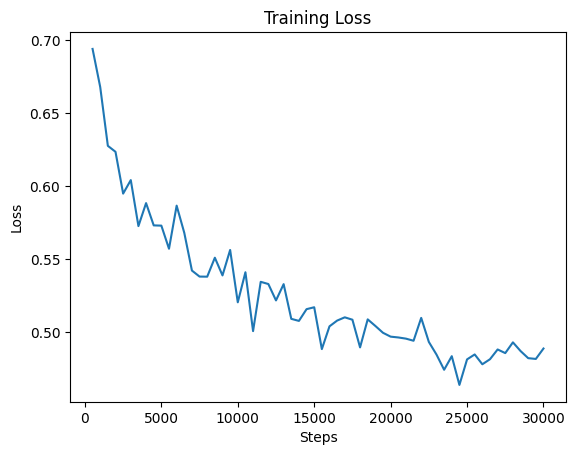

In [ ]:
logs = trainer.state.log_history

df_logs = pd.DataFrame(logs)

# Filtrar solo loss
df_loss = df_logs[df_logs["loss"].notna()]

plt.plot(df_loss["step"], df_loss["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Se observa que la función de pérdida disminuye de forma significativa en las primeras iteraciones, pero tiende a estabilizarse en etapas finales. Esto indica que el modelo ha alcanzado un punto de convergencia donde seguir entrenando aportaría mejoras marginales.

In [ ]:
# Ruta donde se ha guardado el modelo
ruta = "/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/models/gpt2_model_final"

# Cargar modelo y tokenizer
tokenizer = AutoTokenizer.from_pretrained(ruta)
model = AutoModelForCausalLM.from_pretrained(ruta)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

A diferencia de las tareas de clasificación, en este caso no existe una métrica de accuracy directa para evaluar el modelo generativo. Métricas como BLEU o ROUGE (que comparan la similitud entre el texto generado y una referencia) no resultan adecuadas, ya que un mismo mensaje puede expresarse de muchas formas diferentes. Por ello, la evaluación se basa principalmente en un análisis cualitativo, generando múltiples ejemplos y valorando la coherencia, relevancia y naturalidad de las respuestas.


## Pruebas realizadas

### 1. Encontrar estilos de participantes

En esta prueba se genera texto a partir de un mismo inicio para diferentes participantes, con el objetivo de observar si el modelo es capaz de capturar estilos de comunicación distintos.


In [ ]:
def generate_with_prompt(person, start_text, max_len=150):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    prompt = f"[{person}] {start_text}"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_length=max_len,
        min_length=20,
        do_sample=True,
        temperature=0.9,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return text

In [ ]:
generate_with_prompt("Claudia", "tia no sabeis")

'[Claudia] tia no sabeis quien ese se habrá q cagarse'

In [ ]:
generate_with_prompt("Claudia", "tia no puedo")

'[Claudia] tia no puedo ni una foto pero yo creo q es un mensaje y esta noche no sabes q si me dijo algo de mi madre jiji seguro'

In [ ]:
generate_with_prompt("Paula", "tia no sabeis")

'[Paula] tia no sabeis estar algo q me digais el miercoles'

En estos resultados se observa que, en algunos casos, el modelo genera frases con menor coherencia. Por este motivo, se ajustan distintos parámetros de generación con el objetivo de reducir la creatividad y obtener respuestas más coherentes y controladas.


In [ ]:
def generate_with_prompt(persona, inicio, max_len=150):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    prompt = f"[{persona}] {inicio}"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
    **inputs,
    max_length=150,
    min_length=20,
    do_sample=True,
    temperature=0.70,
    top_p=0.9,
    top_k=40,
    repetition_penalty=1.0,
    pad_token_id=tokenizer.eos_token_id
    )

    texto = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(texto)

In [ ]:
generate_with_prompt("Claudia", "tia no sabeis")

[Claudia] tia no sabeis q no me da tiempo ni de coña


In [ ]:
generate_with_prompt("Claudia", "tias no sabeis")

[Claudia] tias no sabeis nada q m he quedado llorar


Debido a que las participantes forman parte de nuestro entorno, se puede observar que el modelo logra capturar ciertos rasgos de personalidad. En el caso de Claudia, tiende a generar respuestas relacionadas con falta de tiempo o agobio, lo que coincide con su forma habitual de comunicarse.

In [ ]:
generate_with_prompt("Paula", "tia no sabeis")

[Paula] tia no sabeis q estoy en mi casa no me apetecia nada


In [ ]:
generate_with_prompt("Paula", "tias no sabeis")

[Paula] tias no sabeis quedar con el viaje y no me gusta


Por otro lado, en el caso de Paula se observa que el modelo genera respuestas coherentes con un estilo directo, sincero y organizado, reflejando su papel habitual como organizadora y su tendencia a expresar con claridad cuando algo no le apetece. Además, incorpora rasgos propios del lenguaje informal de WhatsApp, como el uso de abreviaciones (“q” en lugar de “que”) y expresiones coloquiales, lo que refuerza la naturalidad de las respuestas generadas.


In [ ]:
generate_with_prompt("Angela", "tia no sabeis")

[Angela] tia no sabeis q se lo he enterado más o menos


In [ ]:
generate_with_prompt("Angela", "tias no sabeis")

[Angela] tias no sabeis quien es jueves pero no sabía q tengo una cosa de q tengo q contar q no es una cosa y q le había pasado tú ojalá y tengo q contar y q es el piso tú tienen todas no


En el caso de Ángela, el modelo tiende a generar mensajes más largos, en línea con lo observado en el EDA. Además se refleja su estilo comunicativo, ya que suele aprovechar WhatsApp para contar experiencias y cotilleos, al ser la participante con la que menos interacción presencial se tiene.


In [ ]:
generate_with_prompt("Carmen", "tia no sabeis")

[Carmen] tia no sabeis lo q habia leido en la biblio


In [ ]:
generate_with_prompt("Carmen", "tias no sabeis")

[Carmen] tias no sabeis q no puedo decir jajajajajajaj


En el caso de Carmen, el modelo genera respuestas coherentes con su estilo, haciendo referencia a su rutina de estudio, como el uso de la biblioteca. Además, es frecuente la presencia de risas en los mensajes, lo que refleja su forma habitual de comunicarse.


En general, el modelo es capaz de generar respuestas coherentes y adaptadas al hablante, capturando ciertos patrones de estilo. No obstante, en algunos casos se observan pequeñas incoherencias, lo cual es esperable dado que se trabaja con mensajes de WhatsApp cortos, donde el contexto es limitado y las frases suelen ser incompletas.



### 2. Coherencia en la generación
En esta prueba se evalúa la capacidad del modelo para continuar frases incompletas, analizando si mantiene coherencia y sentido en la generación.


In [ ]:
generate_with_prompt("Claudia", "tia no puedo ir hoy porque")

[Claudia] tia no puedo ir hoy porque no puedo ir a las 


In [ ]:
generate_with_prompt("Claudia", "tia no puedo ir hoy porque")

[Claudia] tia no puedo ir hoy porque parece q no tienen q ir a las  pero si no quereis vosotras tienes q ir a la fiesta q m da mucho miedo


In [ ]:
generate_with_prompt("Paula", "tia no puedo ir hoy porque")

[Paula] tia no puedo ir hoy porque no se puede


In [ ]:
generate_with_prompt("Paula", "tia no puedo ir hoy porque")

[Paula] tia no puedo ir hoy porque tengo una cosa de  a 


In [ ]:
generate_with_prompt("Carmen", "tia no puedo ir hoy porque")

[Carmen] tia no puedo ir hoy porque se va a llover


'[Carmen] tia no puedo ir hoy porque se va a llover'

In [ ]:
generate_with_prompt("Carmen", "tia no puedo ir hoy porque")

[Carmen] tia no puedo ir hoy porque me hacen la biblio


'[Carmen] tia no puedo ir hoy porque me hacen la biblio'

In [ ]:
generate_with_prompt("Angela", "tia no puedo ir hoy porque")

'[Angela] tia no puedo ir hoy porque voy a mirar vuelve el metro xq es mas si q seguimos una idea'

In [ ]:
generate_with_prompt("Angela", "tia no puedo ir hoy porque")

[Angela] tia no puedo ir hoy porque es muy tarde


En general, se observa que el modelo es capaz de continuar las frases de forma coherente en todos los casos, generando respuestas con sentido y acordes al contexto inicial. En este caso, al partir de una frase como “no puedo ir hoy porque”, es habitual que el modelo genere continuaciones con contenido negativo o justificativo, ya que está aprendiendo a completar la causa de una imposibilidad.

### 3. Generación de conversaciones
En esta prueba se introduce un contexto conversacional previo para analizar si el modelo es capaz de generar respuestas coherentes en función del diálogo.


In [ ]:
def generate_response(chat, persona):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Forzamos nueva línea con persona
    prompt = chat + f"\n[{persona}] "

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_length=len(inputs["input_ids"][0]) + 30,  # SOLO un poco más
        do_sample=True,
        temperature=0.80,
        top_p=0.95,
        repetition_penalty=1.0,
        pad_token_id=tokenizer.eos_token_id
    )

    texto = tokenizer.decode(outputs[0], skip_special_tokens=True)

    #  Nos quedamos SOLO con lo nuevo
    respuesta = texto[len(prompt):].split("\n")[0].strip()

    return f"[{persona}] {respuesta}"

In [ ]:
import random

personas = ["Claudia", "Paula", "Carmen", "Angela"]

def simulate_chat(chat_inicial, n_turnos=5):
    chat = chat_inicial

    for i in range(n_turnos):
        persona = random.choice(personas)

        respuesta = generate_response(chat, persona)

        print(f"\n--- Turno {i+1} ---")
        print(respuesta)

        chat += "\n" + respuesta

In [ ]:
chat_inicial = """[Paula] tias mañana hacemos algo?
[Claudia] no se tengo que estudiar
[Paula] venga solo un rato"""

simulate_chat(chat_inicial, n_turnos=1)


--- Turno 1 ---
[Angela] si quereis


In [ ]:
chat_inicial = """[Paula] tias mañana hacemos algo?
[Claudia] no se tengo que estudiar
[Paula] venga solo un rato"""

simulate_chat(chat_inicial, n_turnos=1)


--- Turno 1 ---
[Angela] iba a decir q estoy


In [ ]:
chat_inicial = """[Paula] tias mañana hacemos algo?
[Claudia] no se tengo que estudiar
[Paula] venga solo un rato"""

simulate_chat(chat_inicial, n_turnos=2)


--- Turno 1 ---
[Claudia] que tengo que estudiar

--- Turno 2 ---
[Claudia] 


In [ ]:
chat_inicial = """[Paula] tias mañana hacemos algo?
[Claudia] no sé tengo que estudiar
[Paula] venga solo un rato"""

simulate_chat(chat_inicial, n_turnos=3)


--- Turno 1 ---
[Carmen] me da iguallll

--- Turno 2 ---
[Claudia] 

--- Turno 3 ---
[Paula] porq me voy a decir el viernes


In [ ]:
chat_inicial = """[Paula] tias mañana hacemos algo?
[Claudia] no se tengo que estudiar
[Paula] venga solo un rato"""

simulate_chat(chat_inicial, n_turnos=3)


--- Turno 1 ---
[Angela] 

--- Turno 2 ---
[Paula] siiii

--- Turno 3 ---
[Carmen] en plan si quereis vosotras


In [ ]:
chat_inicial = """[Paula] tias mañana hacemos algo?
[Claudia] no se tengo que estudiar
[Paula] venga solo un rato"""

simulate_chat(chat_inicial, n_turnos=3)


--- Turno 1 ---
[Carmen] iba a decir a mi me da igual

--- Turno 2 ---
[Paula] iba a ir algo a ver que no me importa la verdad

--- Turno 3 ---
[Angela] iba a mirar


A partir de estas pruebas se observa que el modelo es capaz de generar respuestas coherentes teniendo en cuenta el contexto inicial de la conversación.

Asimismo, al aumentar el número de turnos, se aprecia una ligera pérdida de coherencia, lo cual es habitual en modelos generativos, especialmente cuando se trabaja con mensajes cortos y contextos limitados.

En general, el modelo muestra un buen comportamiento en contextos cortos, aunque presenta dificultades para mantener la consistencia en conversaciones más largas.
